In [1]:
import numpy as np 
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import random

### three doors

In [3]:
n = 3 # doors
n_sim = 10000  # simulations

#count
n_switch = 0
n_conservative = 0
n_last_arrival = 0 

for i in range(n_sim): 
    
    doors = np.array(["g"] * n)
    pos = np.arange(n)
    c_pos = np.random.choice(pos) #position of the car
    doors[c_pos] = "c" # "rename" c with chosen position
    choosen_door_pos = np.random.choice(pos)
    
    #doors that Monty can open (with goat) 
    g_doors_pos = []
    for j in pos:
        if j != choosen_door_pos and doors[j] == "g":
            g_doors_pos.append(j)
    
    # Monty open one door
    monty_opens_pos = None
    if g_doors_pos:
        monty_opens_pos = np.random.choice(g_doors_pos)
    
    switch_choice_pos = None
    last_arrival_choise_pos = None
    
    for k in pos:
        if k != monty_opens_pos:
            last_arrival_choise_pos = k
            if k != choosen_door_pos:
                switch_choice_pos = k
    

    if doors[switch_choice_pos] == "c":
        n_switch += 1
    
    if doors[last_arrival_choise_pos] == "c":
        n_last_arrival += 1

    if doors[choosen_door_pos] == "c":
        n_conservative += 1

# estimated probability
p_switch = n_switch / n_sim
p_last_arrival = n_last_arrival / n_sim
p_conservative = n_conservative / n_sim

print("Prob switch door:", p_switch)
print("Prob last arrival:", p_last_arrival)
print("Prob conservative:", p_conservative)

Prob switch door: 0.6643
Prob last arrival: 0.4998
Prob conservative: 0.3357


<BarContainer object of 1 artists>

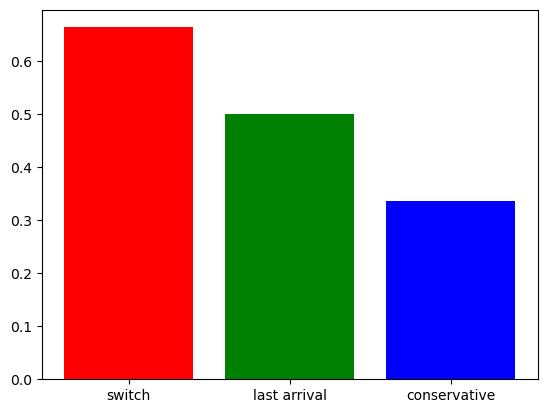

In [4]:
plt.bar("switch", p_switch, color="red")
plt.bar("last arrival", p_last_arrival, color="green")
plt.bar("conservative", p_conservative, color="blue")

In [6]:
#count
n_switch = 0
n_conservative = 0
n_last_arrival = 0 

steps = []
probs_switch = []
probs_last = []
probs_conservative = []

#want to see what happens for the first 1000 steps (can also change the number of steps to see what happens)
for i in tqdm(range(1, 1000 + 1)):
    
    doors = np.array(["g"] * n)
    pos = np.arange(n)
    c_pos = np.random.choice(pos)
    doors[c_pos] = "c"  
    choosen_door_pos = np.random.choice(pos)
    
    # doors that mounty can open 
    g_doors_pos = []
    for j in pos:
        if j != choosen_door_pos and doors[j] == "g":
            g_doors_pos.append(j)
    
    # Monty opens one door
    monty_opens_pos = None
    if g_doors_pos:  
        monty_opens_pos = np.random.choice(g_doors_pos)
    
    switch_choice_pos = None
    last_arrival_choise_pos = None
    
    for k in pos:
        if k != monty_opens_pos:
            last_arrival_choise_pos = k
            if k != choosen_door_pos:
                switch_choice_pos = k
    

    if doors[switch_choice_pos] == "c":
        n_switch += 1
    
    if doors[last_arrival_choise_pos] == "c":
        n_last_arrival += 1

    if doors[choosen_door_pos] == "c":
        n_conservative += 1

    steps.append(i) #step 
    probs_switch.append(n_switch /i) 
    probs_last.append(n_last_arrival /i)
    probs_conservative.append(n_conservative /i)

#print(probs_switch)

  0%|          | 0/1000 [00:00<?, ?it/s]

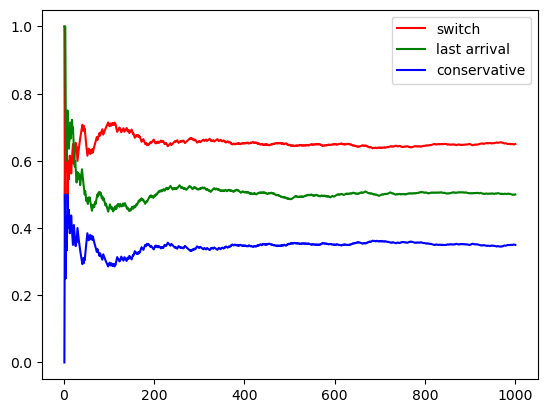

In [7]:
plt.plot(steps, probs_switch, label="switch", color="red")
plt.plot(steps, probs_last, label="last arrival", color="green")
plt.plot(steps, probs_conservative, label="conservative", color="blue")
plt.legend()

we see there is a convergence

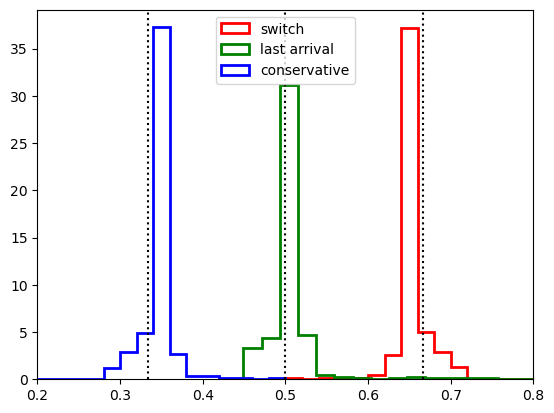

In [13]:
plt.hist(probs_switch,density=True, bins=25, histtype='step', lw=2, label="switch", color="red")
plt.hist(probs_last,density=True, histtype='step', bins=25, lw =2, label="last arrival", color="green")
plt.hist(probs_conservative,density=True, histtype='step', bins=25, lw=2, label="conservative", color="blue")
plt.xlim(0.2, 0.8)
plt.axvline(1/3, ls='dotted',c='black')
plt.axvline(1/2, ls='dotted',c='black')
plt.axvline(2/3, ls='dotted',c='black')
plt.legend()

error scale as the inverse of the square root of N (number of points)

## N doors

In [17]:
n = 14 # number of doors
n_sim = 10000  # number of simulation
p = 5 # number of doors opened by monty

#count
n_switch = 0
n_conservative = 0
n_last_arrival = 0 


if (p < n-2): 
    for i in range(n_sim): 
        doors = np.array(["g"] * n)
        pos = np.arange(n)
        c_pos = np.random.choice(pos)  
        doors[c_pos] = "c" 
        choosen_door_pos = np.random.choice(pos)
        mask_not_choosen_pos = (pos != choosen_door_pos)
    
        # door that monty can open (with g) 
        g_doors_pos = []
        for j in pos:
            if j != choosen_door_pos and doors[j] == "g":
                g_doors_pos.append(j)
    
        # Monty open p doors
        monty_opens_pos = []
        if g_doors_pos: 
            monty_opens_pos = random.sample(g_doors_pos, p)

        switch_choice_pos = None
        last_arrival_choise_pos = None

        remain_door_pos_last_arrival = np.setdiff1d(pos, monty_opens_pos) #può scegliere anche quella scelta da altro giocatore
        remain_door_pos_switch = np.setdiff1d(pos[mask_not_choosen_pos], monty_opens_pos)
    
        last_arrival_choise_pos = np.random.choice(remain_door_pos_last_arrival)
        switch_choice_pos = np.random.choice(remain_door_pos_switch)
    

        if doors[switch_choice_pos] == "c":
            n_switch += 1
    
        if doors[last_arrival_choise_pos] == "c":
            n_last_arrival += 1

        if doors[choosen_door_pos] == "c":
            n_conservative += 1
else:
    print("insert another number please!!")

# prob
p_switch = n_switch / n_sim
p_last_arrival = n_last_arrival / n_sim
p_conservative = n_conservative / n_sim

print("Prob switch:", p_switch)
print("Prob last arrival:", p_last_arrival)
print("Prob conservative:", p_conservative)

Prob switch: 0.1174
Prob last arrival: 0.1119
Prob conservative: 0.0758


In [18]:
predicted_p_switch = (1/n)*(n-1)/(n-p-1)
print("predicted switch:") 
print(predicted_p_switch)
print("predicted last arrival:") 
print(1/(n-p))
print("predicted conservative:")
print(1/n)

predicted switch:
0.11607142857142856
predicted last arrival:
0.1111111111111111
predicted conservative:
0.07142857142857142
